In [55]:
import os
import json
import random

from PIL import Image

import pandas as pd
import matplotlib.pyplot as plt

In [56]:
# /!\/!\/!\ TEMPORARY LOCATION FOR ALL CSVs
CSV_PATH = "/dtu-compute/ofhkr/p4workspace/metadata"

In [57]:
MML_PATH = "/dtu/blackhole/02/137570/MML"
# CSV_PATH = os.path.join(MML_PATH,"metadata")

## Dataset overview

In [58]:
mmlandmarks = pd.read_csv(os.path.join(CSV_PATH,"mmlandmarks.csv"))
mmlandmarks.head()

,landmark_id,CommonsCategory,WikipediaPage,lat,lon,min_lat,min_lon,max_lat,max_lon,QID,osm_type,osm_id,category,state,hierarchical_category
0,1,Kent Free Library,Kent Free Library,41.153332,-81.361273,41.153031,-81.361761,41.153632,-81.360786,Q6391730,way,234700261,library,Ohio,library
1,2,Chapel of the Good Shepherd (Roosevelt Island),Chapel of the Good Shepherd (Roosevelt Island),40.761850,-73.950242,40.761718,-73.950463,40.761981,-73.950022,Q5073113,way,284879988,chapel,New York,church
2,3,Keeler Tavern,Keeler Tavern,41.273190,-73.496222,41.272860,-73.497103,41.273519,-73.495341,Q6382775,way,310838217,historic building,Connecticut,government building
3,4,National Safety Council,National Safety Council,41.965399,-88.029859,41.965118,-88.030415,41.965681,-88.029303,Q6978225,way,525157159,nonprofit organization,Illinois,artwork
4,5,"Firehouse, Engine Company 31","Firehouse, Engine Company 31",40.717298,-74.001148,40.717128,-74.001385,40.717467,-74.000911,Q5451867,way,285940922,fire station,New York,government building


In [59]:
mml_train = pd.read_csv(os.path.join(CSV_PATH,"mml_train.csv"))
mml_query = pd.read_csv(os.path.join(CSV_PATH,"mml_query.csv"))

### Let's choose a landmark and determine which directory it is from (train or query):

In [71]:
IDX = 1234

chosen_landmark = int(mmlandmarks["landmark_id"].iloc[IDX])
print(f"{chosen_landmark=}")

folder = "train" if chosen_landmark in list(mml_train["landmark_id"]) else "query"
print(f"{folder=}")

chosen_landmark=1235
folder='train'


## Visualization

In [72]:
mml = mml_train if folder == "train" else mml_query

In [73]:
# Information about the landmark id and location of the corresponding ground image files
mml_ground = pd.read_csv(os.path.join(CSV_PATH,f"mml_{folder}_ground.csv"))
mml_ground.head()

,landmark_id,images
0,1,b6e40405d61d4658 0ebf9ff497cc475a 95db11a10bd3...
1,2,70241212b34cc50c a4383a96c1bf934f 518f864d6bde...
2,3,a128454c23166203 b17c9a50f4027c01 bc945f6529fc...
3,4,3da849cc4818c06f 43335e920f50d00a 00a8a99bc05d...
4,5,4d0870ce1c124363 93dd74795794ac5b 65c1aded745c...


In [74]:
# Information about the landmark id and location of the corresponding satellite image files
mml_satellite = pd.read_csv(os.path.join(CSV_PATH,f"mml_{folder}_satellite.csv"))
mml_satellite.head()

,landmark_id,images
0,1,c8ea40a5178db5c3 112d01d5b11f841e a1249a655c8e...
1,2,1fc9534ea77135e6 7fcefd60d1378961 6b30e70bd7ef...
2,3,a373c827944534fb 9e0f132aaad004be
3,4,fdfc33ce48843089 3551318cecb43ea6 819550b0634b...
4,5,10607cc7c46a2a24 8f4e2ade124b0afd bfa6a2b5a09b...


In [75]:
# Information about the landmark id and location of the corresponding json text files
mml_text = pd.read_csv(os.path.join(CSV_PATH,f"mml_{folder}_text.csv"))
mml_text.head()

,landmark_id,json
0,1,5a9087ecc3602a48
1,2,cf5dfb543ca2d7d6
2,3,ad1f723f20b9aba5
3,4,de2a2e4faa8aff62
4,5,7713e1dfd8f81973


In [76]:
# Information about the GPS coordinates
mml.head()

,landmark_id,CommonsCategory,lat,lon
0,1,Kent Free Library,41.153332,-81.361273
1,2,Chapel of the Good Shepherd (Roosevelt Island),40.761850,-73.950242
2,3,Keeler Tavern,41.273190,-73.496222
3,4,National Safety Council,41.965399,-88.029859
4,5,"Firehouse, Engine Company 31",40.717298,-74.001148


Given our landmark of interest, we use the `landmark_id` to find the location of the ground images, satellite images, and text information.</br>
We used the first landmark from the train set, the Kent Free Library, as an example.

There are four modalities associated with the landmarks:
- Ground: "b6e40405d61d4658 0ebf9ff497cc475a 95db11a10bd3..." - from `mml_train_ground.csv`
- Satellite: "c8ea40a5178db5c3 112d01d5b11f841e a1249a655c8e..." - from `mml_train_satellite.csv`
- Text: "5a9087ecc3602a48" - from `mml_train_text.csv`
- GPS: (41.153332,-81.361273) - from `mml_train.csv`

For ground, satellite and text, the names and folders follow the structure:</br>

`${a}/${b}/${c}/${id}.ext`

where `ext` depends on the modality (`{ground: '.jpg', satellite: '.png', text: '.json'}`) and `${a}`,`${b}`,`${c}` are the first 3 characters of `${id}`. </br>
As an example, the ground image `0123456789abcdef` will be stored in 

`0/1/2/0123456789abcdef.jpg`



In [77]:
# Ground images

ground_files = mml_ground[mml_ground["landmark_id"]==chosen_landmark]
ground_images = []

for file in ground_files["images"].item().split(" "):
    
    path = os.path.join(MML_PATH, f"{folder}", "ground", file[0], file[1], file[2], f"{file}.jpg")
    
    img = Image.open(path)
    ground_images.append(img)
    
print(f"There are {len(ground_images)} ground images associated with this landmark")

There are 17 ground images associated with this landmark


In [78]:
# Satellite images

satellite_files = mml_satellite[mml_satellite["landmark_id"]==chosen_landmark]
satellite_images = []

for file in satellite_files["images"].item().split(" "):
    
    path = os.path.join(MML_PATH, f"{folder}", "satellite", file[0], file[1], file[2], f"{file}.png")
    
    img = Image.open(path)
    satellite_images.append(img)
    
print(f"There are {len(satellite_images)} satellite images associated with this landmark")

There are 10 satellite images associated with this landmark


In [79]:
# Text information

text_file = mml_text[mml_text["landmark_id"]==chosen_landmark]

file = text_file["json"].item()

path = os.path.join(MML_PATH, f"{folder}", "text", file[0], file[1], file[2], f"{file}.json")

with open(path, "r") as f:
    text = json.load(f)

print(json.dumps(text, indent=4))

{
    "Introduction": "The Wye Mill is the oldest continuously operated grist mill in the United States, located at Wye Mills, Queen Anne's County and Talbot County, Maryland, United States. It is the earliest industrial site on the Eastern Shore in continuous use; dating to the late 17th century. It is a wood-frame, water-powered grist mill, with a 19th-century 26 HP 10-foot-diameter (3.0 m) Fitz steel overshot wheel. The mill retains nearly all of its late-18th-century equipment. The Wye Mill was one of the first grist mills to be automated with the Oliver Evans process, which is still in use today.\nThe Wye Mill was listed on the National Register of Historic Places in 1985."
}


## Wrapping it all together:

In [80]:
meta = mmlandmarks[mmlandmarks["landmark_id"] == chosen_landmark].iloc[0]

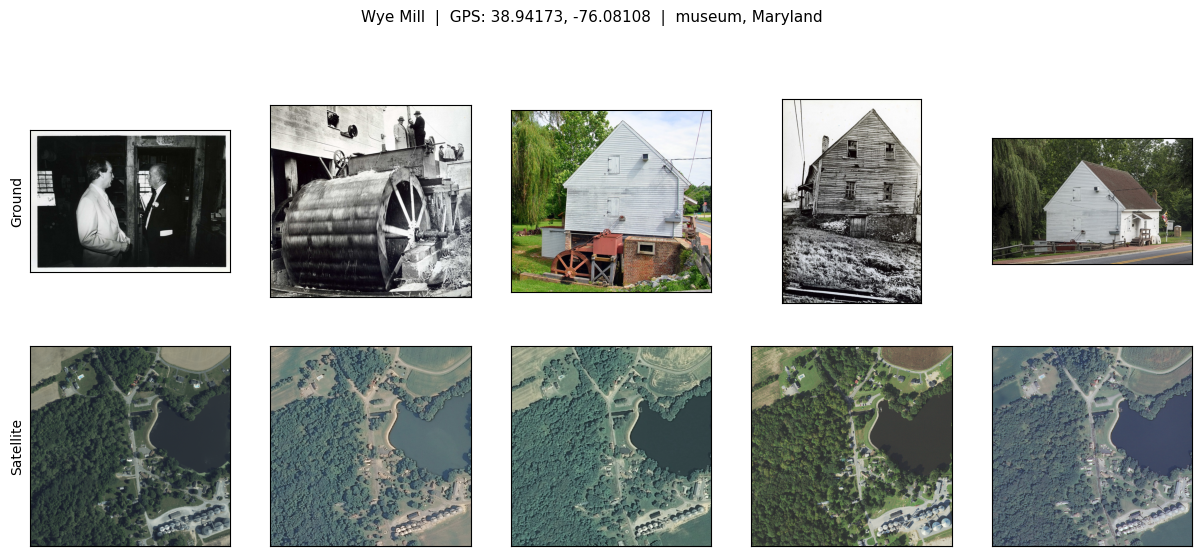

- 17 ground images.
- 10 satellite images.
- GPS location: 38.94173, -76.08108
- Text information:
{
    "Introduction": "The Wye Mill is the oldest continuously operated grist mill in the United States, located at Wye Mills, Queen Anne's County and Talbot County, Maryland, United States. It is the earliest industrial site on the Eastern Shore in continuous use; dating to the late 17th century. It is a wood-frame, water-powered grist mill, with a 19th-century 26 HP 10-foot-diameter (3.0 m) Fitz steel overshot wheel. The mill retains nearly all of its late-18th-century equipment. The Wye Mill was one of the first grist mills to be automated with the Oliver Evans process, which is still in use today.\nThe Wye Mill was listed on the National Register of Historic Places in 1985."
}
Useful additional information:
Wikimedia Commons Link: https://commons.wikimedia.org/wiki/Category:Wye_Mill
Wikipedia Link: https://en.wikipedia.org/wiki/Wye_Mill
OSM information Link: https://www.openstreetmap.

In [81]:
n = 5
sample_ground = random.sample(ground_images, min(n, len(ground_images)))
sample_sat    = random.sample(satellite_images, min(n, len(satellite_images)))

fig, axes = plt.subplots(3, n, figsize=(15, 9))
fig.suptitle(
    f"{meta['CommonsCategory']}  |  GPS: {meta['lat']:.5f}, {meta['lon']:.5f}"
    f"  |  {meta['hierarchical_category']}, {meta['state']}",
    fontsize=11
)

for i in range(n):
    for row, imgs, label in [(0, sample_ground, "Ground"), (1, sample_sat, "Satellite")]:
        ax = axes[row, i]
        if i < len(imgs):
            ax.imshow(imgs[i])
        else:
            ax.set_visible(False)
        ax.set_xticks([]); ax.set_yticks([])
        if i == 0:
            ax.set_ylabel(label, fontsize=10)

# Text row
for ax in axes[2]:
    ax.set_visible(False)
plt.show()

print(f"- {len(ground_images)} ground images.")
print(f"- {len(satellite_images)} satellite images.")
print(f"- GPS location: {meta['lat']:.5f}, {meta['lon']:.5f}")
print("- Text information:")
print(json.dumps(text,indent=4))

print(45*"=")
print("Useful additional information:")
print(f"Wikimedia Commons Link: https://commons.wikimedia.org/wiki/Category:{meta['CommonsCategory'].replace(' ','_')}")
print(f"Wikipedia Link: https://en.wikipedia.org/wiki/{meta['WikipediaPage'].replace(' ','_')}")
print(f"OSM information Link: https://www.openstreetmap.org/{meta['osm_type']}/{meta['osm_id']}")